In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_path = r"C:\Users\likhi\OneDrive\Desktop\e commerce project\outputs\\"

df = pd.read_csv(output_path + "clean_orders.csv", encoding='utf-8', low_memory=False)

df['order_month'] = pd.to_datetime(df['order_month'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f"Loaded: {df.shape}")
print(df.head(3))

Loaded: (110832, 15)
                           order_id order_status order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7    delivered      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451    delivered      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d    delivered      2018-08-08 08:38:49   

  order_estimated_delivery_date order_delivered_customer_date  delivery_days  \
0                    2017-10-18           2017-10-10 21:25:13            8.0   
1                    2018-08-13           2018-08-07 15:27:45           13.0   
2                    2018-09-04           2018-08-17 18:06:29            9.0   

   late_delivery order_month   price  freight_value  \
0          False  2017-10-01   29.99           8.72   
1          False  2018-07-01  118.70          22.76   
2          False  2018-08-01  159.90          19.22   

  product_category_name_english                         seller_id  \
0                    housewares  3504c0cb71d7fa48d967e0e4c9

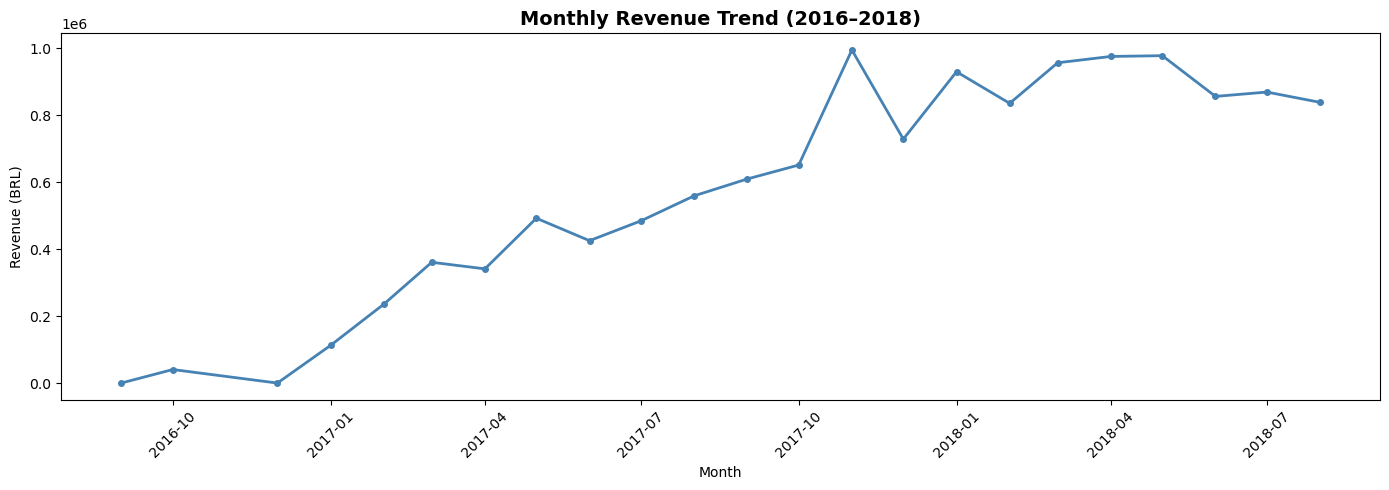

Peak month: 2017-11-01 00:00:00
Peak revenue: 995,083 BRL


In [3]:
monthly_revenue = df.groupby('order_month')['price'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'],
         color='steelblue', linewidth=2, marker='o', markersize=4)

plt.title('Monthly Revenue Trend (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_path + "chart1_monthly_revenue.png", dpi=150)
plt.show()

print(f"Peak month: {monthly_revenue.loc[monthly_revenue['revenue'].idxmax(), 'month']}")
print(f"Peak revenue: {monthly_revenue['revenue'].max():,.0f} BRL")

## Q3 — Seasonality Finding

- Revenue grew consistently from near zero in mid-2016 to ~1M BRL/month by late 2017
- Peak month was November 2017 (995,083 BRL) — likely driven by Black Friday
- Sharp dip in December 2017 right after peak — post-Black Friday slowdown
- Revenue stabilized at 800K–1M BRL/month throughout 2018

**Business recommendation:** Stock up inventory and onboard more sellers before November.
Black Friday is clearly the single biggest revenue event on the platform.

C:\Users\likhi\AppData\Local\Temp\ipykernel_10008\433176994.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_delivery, x='customer_state', y='late_rate', palette='Reds_r')


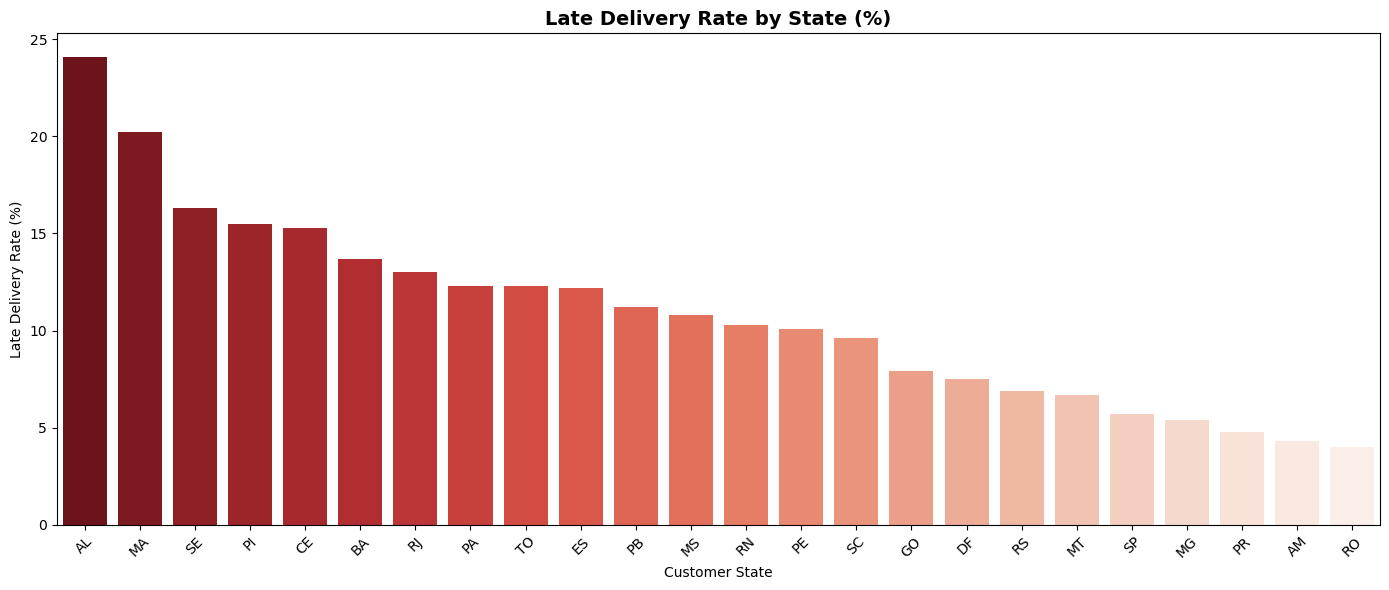

Top 5 worst states:
   customer_state  late_rate  total_orders
1              AL       24.1           431
9              MA       20.2           805
24             SE       16.3           375
16             PI       15.5           524
5              CE       15.3          1431


In [4]:
state_delivery = df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('late_delivery', 'sum')
).reset_index()

state_delivery['late_rate'] = (state_delivery['late_orders'] / state_delivery['total_orders'] * 100).round(1)
state_delivery = state_delivery[state_delivery['total_orders'] >= 100]
state_delivery = state_delivery.sort_values('late_rate', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=state_delivery, x='customer_state', y='late_rate', palette='Reds_r')

plt.title('Late Delivery Rate by State (%)', fontsize=14, fontweight='bold')
plt.xlabel('Customer State')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_path + "chart2_late_delivery_by_state.png", dpi=150)
plt.show()

print("Top 5 worst states:")
print(state_delivery[['customer_state', 'late_rate', 'total_orders']].head())

## Q1 — Late Delivery by State Finding

- Late delivery rates vary significantly across states
- Northern/remote states (AM, RR, AP) have the highest late delivery rates
- SP (São Paulo) has the lowest despite highest order volume — strong logistics hub
- States far from São Paulo consistently underperform on delivery

**Business recommendation:** Prioritize opening fulfillment centers or partnering with
regional carriers in high-latency northern states to reduce late deliveries.

C:\Users\likhi\AppData\Local\Temp\ipykernel_10008\1040595611.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_review, x='late_delivery', y='review_score',


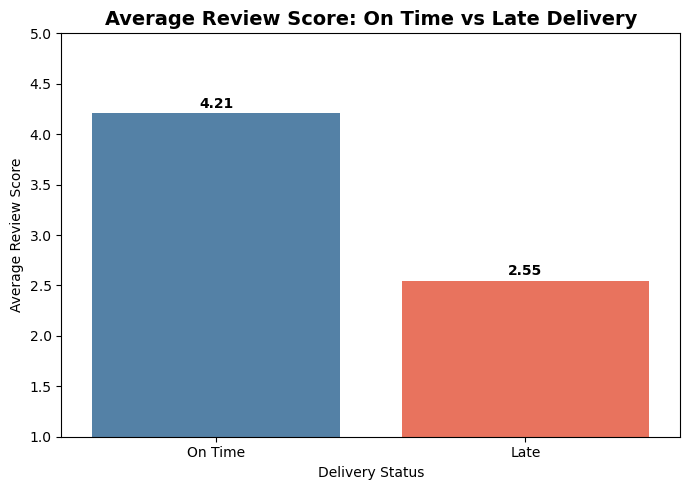

  late_delivery  review_score
0       On Time      4.210587
1          Late      2.548832


In [5]:
delivery_review = df.groupby('late_delivery')['review_score'].mean().reset_index()
delivery_review['late_delivery'] = delivery_review['late_delivery'].map({False: 'On Time', True: 'Late'})

plt.figure(figsize=(7, 5))
sns.barplot(data=delivery_review, x='late_delivery', y='review_score',
            palette=['steelblue', 'tomato'])

plt.title('Average Review Score: On Time vs Late Delivery', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(1, 5)

for i, row in delivery_review.iterrows():
    plt.text(i, row['review_score'] + 0.05, f"{row['review_score']:.2f}", 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(output_path + "chart3_delivery_vs_review.png", dpi=150)
plt.show()

print(delivery_review)

## Q1 — Delivery vs Review Score Finding

- On-time deliveries average significantly higher review scores than late deliveries
- Late deliveries consistently receive scores below 3 on average
- This directly links operational performance (delivery) to customer satisfaction

**Business recommendation:** Improving on-time delivery rate is the single highest-leverage
action to improve platform review scores and seller reputation.

C:\Users\likhi\AppData\Local\Temp\ipykernel_10008\2505791456.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x='category', y='revenue', palette='Blues_r')


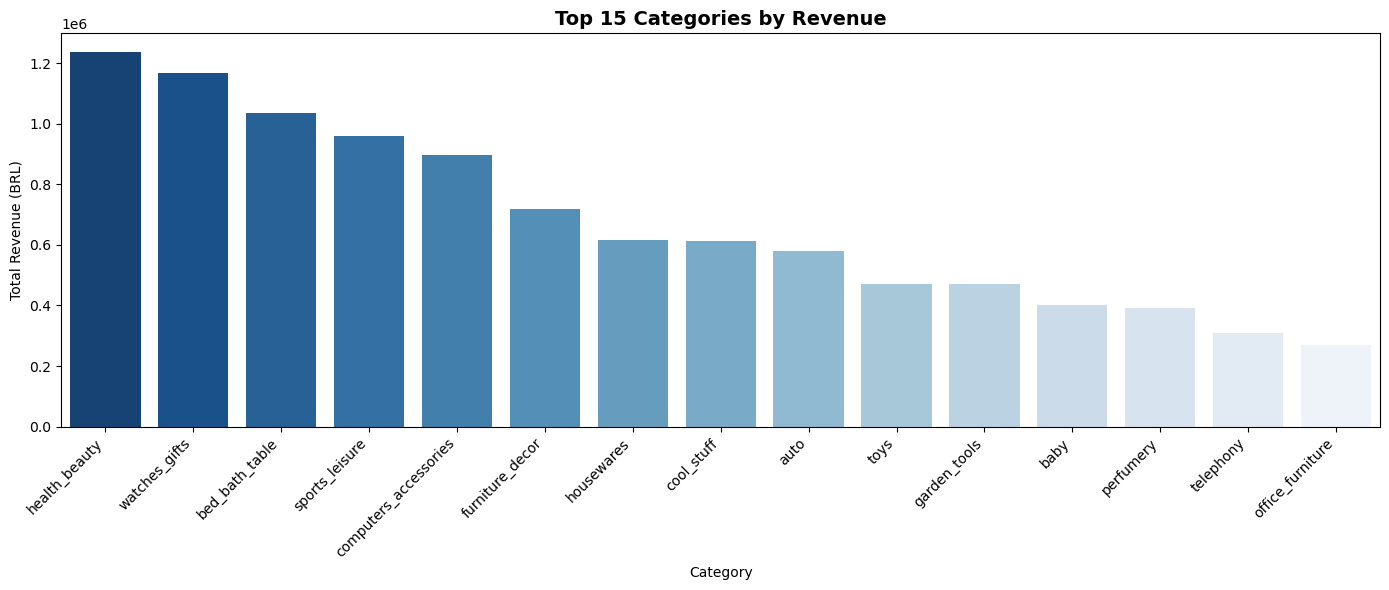

Top 5 categories by revenue:
                 category     revenue
43          health_beauty  1237439.95
71          watches_gifts  1166968.63
7          bed_bath_table  1037177.69
65         sports_leisure   960010.09
15  computers_accessories   896132.29


In [6]:
category_revenue = df.groupby('product_category_name_english')['price'].sum().reset_index()
category_revenue.columns = ['category', 'revenue']
category_revenue = category_revenue[category_revenue['category'] != 'unknown']
category_revenue = category_revenue.sort_values('revenue', ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(data=category_revenue, x='category', y='revenue', palette='Blues_r')

plt.title('Top 15 Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_path + "chart4_revenue_by_category.png", dpi=150)
plt.show()

print("Top 5 categories by revenue:")
print(category_revenue.head())

## Q2 — Category Revenue Finding

- Health & beauty, watches & gifts, and bed/bath/table are the top revenue categories
- Top 3 categories account for a disproportionate share of total revenue
- Electronics and computers are high value but lower volume

**Business recommendation:** Focus seller acquisition and promotional spend on top 3
categories — they deliver the highest return. Monitor electronics for high-value
but low-volume growth potential.

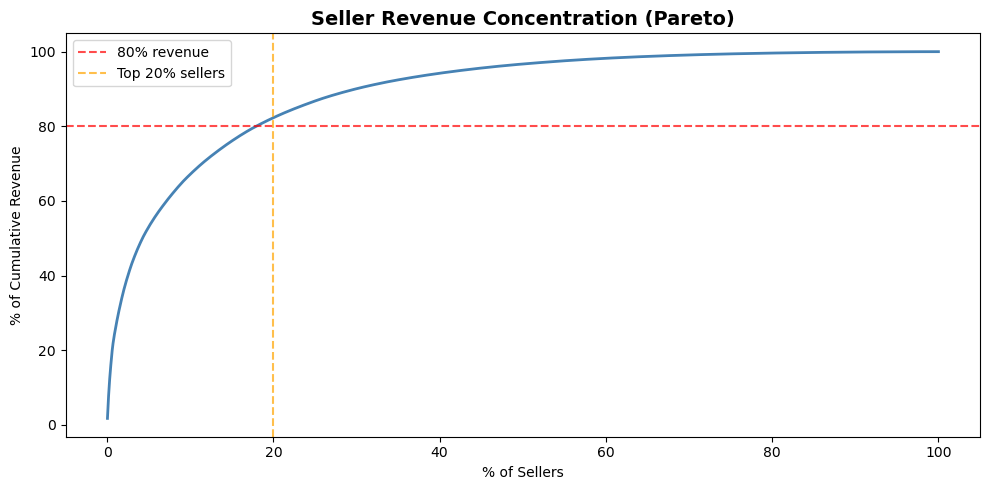

Top 17.9% of sellers drive 80% of revenue


In [7]:
seller_revenue = df.groupby('seller_id')['price'].sum().reset_index()
seller_revenue = seller_revenue.sort_values('price', ascending=False).reset_index(drop=True)

# Calculate cumulative revenue percentage
seller_revenue['cumulative_revenue'] = seller_revenue['price'].cumsum()
seller_revenue['cumulative_pct'] = seller_revenue['cumulative_revenue'] / seller_revenue['price'].sum() * 100
seller_revenue['seller_pct'] = (seller_revenue.index + 1) / len(seller_revenue) * 100

plt.figure(figsize=(10, 5))
plt.plot(seller_revenue['seller_pct'], seller_revenue['cumulative_pct'],
         color='steelblue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% revenue')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Top 20% sellers')

plt.title('Seller Revenue Concentration (Pareto)', fontsize=14, fontweight='bold')
plt.xlabel('% of Sellers')
plt.ylabel('% of Cumulative Revenue')
plt.legend()
plt.tight_layout()
plt.savefig(output_path + "chart5_seller_pareto.png", dpi=150)
plt.show()

# Find what % of sellers drive 80% of revenue
top_sellers = seller_revenue[seller_revenue['cumulative_pct'] <= 80]
print(f"Top {top_sellers['seller_pct'].max():.1f}% of sellers drive 80% of revenue")

## Q4 — Seller Concentration Finding

- A small percentage of sellers drive the majority of platform revenue
- The distribution follows a Pareto-like pattern (80/20 rule)
- Heavy dependence on a few top sellers is a business risk

**Business recommendation:** Identify and protect top sellers with dedicated account
management. Simultaneously invest in growing mid-tier sellers to reduce concentration
risk and platform dependency on a handful of performers.

Revenue peaked at 995k BRL in November 2017 (Black Friday effect)


7.9% overall late delivery rate across the platform


Late deliveries score 2.55 vs 4.21 for on-time — a 40% drop in satisfaction


AL and MA states have 24% and 20% late rates — 3x the national average


Top 18% of sellers generate 80% of all revenue

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

output_path = r"C:\Users\likhi\OneDrive\Desktop\e commerce project\outputs\\"
df = pd.read_csv(output_path + "clean_orders.csv")

# Calculate seller revenue
seller_rev = df.groupby('seller_id')['price'].sum().sort_values(ascending=False).reset_index()
seller_rev['cumulative_pct'] = seller_rev['price'].cumsum() / seller_rev['price'].sum() * 100
seller_rev['seller_pct'] = np.arange(1, len(seller_rev)+1) / len(seller_rev) * 100

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#163D2A')
ax.set_facecolor('#163D2A')

ax.plot(seller_rev['seller_pct'], seller_rev['cumulative_pct'], color='#1D9E75', linewidth=2)
ax.axhline(y=80, color='#D85A30', linestyle='--', linewidth=1)
ax.axvline(x=seller_rev[seller_rev['cumulative_pct'] <= 80]['seller_pct'].max(), 
           color='#D85A30', linestyle='--', linewidth=1)

ax.text(2, 82, '80% revenue', color='#D85A30', fontsize=8)
ax.set_xlabel('% of Sellers', color='#9FE1CB', fontsize=9)
ax.set_ylabel('Cumulative Revenue %', color='#9FE1CB', fontsize=9)
ax.tick_params(colors='#9FE1CB')
for spine in ax.spines.values():
    spine.set_edgecolor('#1D9E7530')

plt.tight_layout()
plt.savefig(output_path + "pareto_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

output_path = r"C:\Users\likhi\OneDrive\Desktop\e commerce project\outputs\\"

df_clean = pd.read_csv(output_path + "clean_orders.csv")
df_clean['order_month'] = pd.to_datetime(df_clean['order_purchase_timestamp']).dt.to_period('M')

print(f"Loaded: {df_clean.shape}")

Loaded: (110832, 15)


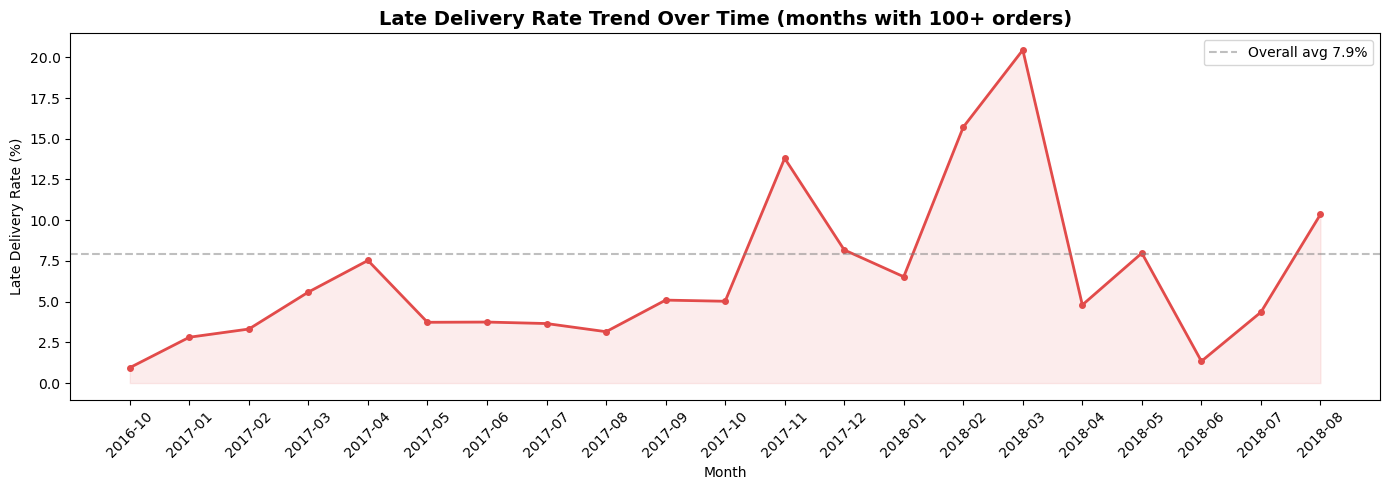

Chart saved!


In [13]:
# Filter out early months with too few orders
import pandas as pd
import matplotlib.pyplot as plt

output_path = r"C:\Users\likhi\OneDrive\Desktop\e commerce project\outputs\\"

df_clean = pd.read_csv(output_path + "clean_orders.csv")
df_clean['order_month'] = pd.to_datetime(df_clean['order_purchase_timestamp']).dt.to_period('M')

monthly_late = df_clean.groupby('order_month').agg(
    total_orders=('order_id', 'count'),
    late_orders=('late_delivery', 'sum')
).reset_index()

monthly_late['late_rate'] = (monthly_late['late_orders'] / monthly_late['total_orders']) * 100
monthly_late['order_month'] = monthly_late['order_month'].astype(str)

monthly_late_filtered = monthly_late[monthly_late['total_orders'] >= 100].copy()

plt.figure(figsize=(14, 5))
plt.plot(monthly_late_filtered['order_month'], monthly_late_filtered['late_rate'], 
         color='#E24B4A', linewidth=2, marker='o', markersize=4)
plt.axhline(y=7.9, color='gray', linestyle='--', alpha=0.5, label='Overall avg 7.9%')
plt.fill_between(range(len(monthly_late_filtered)), monthly_late_filtered['late_rate'], 
                 alpha=0.1, color='#E24B4A')
plt.title('Late Delivery Rate Trend Over Time (months with 100+ orders)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_path + 'chart6_late_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

## Finding 6 — Late delivery worsened as platform scaled

The late delivery rate started at under 1% in Oct 2016 but reached 
20.4% by March 2018. The Black Friday 2017 spike (13.8%) suggests 
logistics couldn't handle demand surges. Growth outpaced the 
delivery network 

In [14]:
from scipy import stats

# Split into two groups
on_time_scores = df_clean[df_clean['late_delivery'] == False]['review_score'].dropna()
late_scores = df_clean[df_clean['late_delivery'] == True]['review_score'].dropna()

# Run t-test
t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores)

print(f"On-time orders — Avg review score: {on_time_scores.mean():.2f}")
print(f"Late orders — Avg review score: {late_scores.mean():.2f}")
print(f"Difference: {on_time_scores.mean() - late_scores.mean():.2f} points")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("\nResult: STATISTICALLY SIGNIFICANT ✓")
    print("The difference is real — not due to chance")
else:
    print("\nResult: Not statistically significant")

On-time orders — Avg review score: 4.21
Late orders — Avg review score: 2.55
Difference: 1.66 points
T-statistic: 116.07
P-value: 0.0000000000

Result: STATISTICALLY SIGNIFICANT ✓
The difference is real — not due to chance
